In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [28]:
dir_geom = 'test_particles/small_spheres'
dir_run = 'test_particles/run_small_spheres'


In [41]:

kabs_list = []
matrix_11_list = []
runs = os.listdir(dir_run)
runs.sort()

for run in runs:
    with open(f'{dir_run}/{run}/results.dat', 'r') as f:
        l = f.readline()
        # skip header
        while l.startswith('#'):
            l=f.readline()
        # now at lambda line
        l=f.readline() #  break

        # comment some of these to pick which lambda result to plot
        l=f.readline() # first data line
        l=f.readline() # second 
        l=f.readline() # third
        
        kabs = float(l.split()[-1])
        lam = float(l.split()[0])
        kabs_list.append(kabs)

        while not l.startswith('#-'):
            l=f.readline()
        l=f.readline()
        l=f.readline() # first matrix line

        matrix_11s = []
        while not l.startswith('#'):
            matrix_11s.append( float(l.split()[1]))
            l=f.readline()
        matrix_11_list.append(matrix_11s)

len(kabs_list)


6

In [42]:


volumes = []
spheres = os.listdir(dir_geom)
spheres.sort()

for sphere in spheres:
    with open(f'{dir_geom}/{sphere}', 'r') as f:
        volume = 0
        l = f.readline()
        while l.startswith('#'):
            if l.startswith('# Volume1'):
                volume += int(l.split()[-1])
            if l.startswith('# Volume2'):
                volume += int(l.split()[-1])

            l=f.readline()
        
        volumes.append(volume)
len(volumes)
        

6

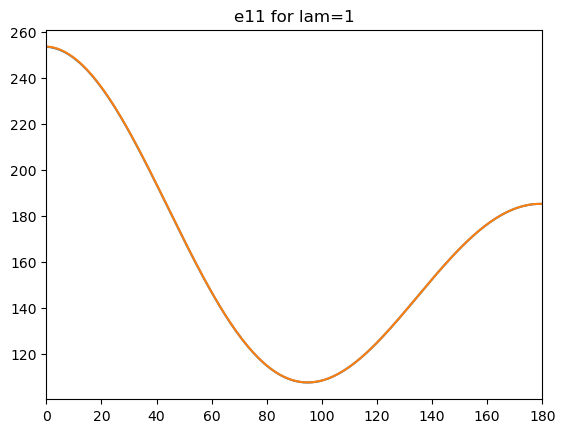

In [ ]:
for matrix_11s in matrix_11_list[4:]:
    plt.plot(range(181), matrix_11s)
plt.title('e11 for lam=1')
plt.xlim(0,180)
plt.show()

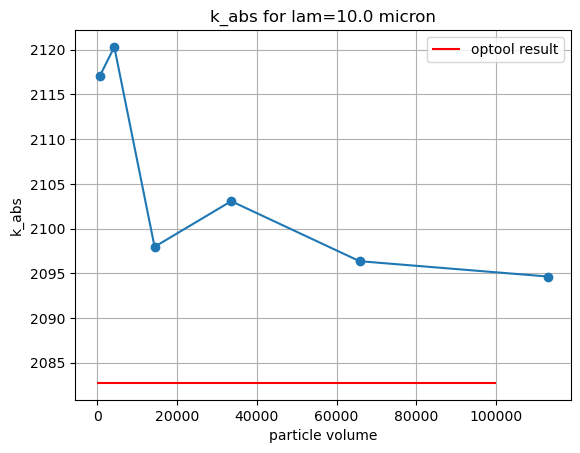

In [44]:
plt.plot(volumes, kabs_list, marker='o')
plt.title(f'k_abs for lam={lam} micron')
plt.ylabel('k_abs')
plt.xlabel('particle volume')
plt.grid()
ymin, ymax = plt.ylim()
# plt.vlines(1500, ymin,ymax, color='red')
# plt.hlines(7.016116E+03, 0, 12000, color='red', label='optool result')
plt.hlines(2.082738E+03
, 0, 100000, color='red', label='optool result')

plt.legend()
plt.show()

to plot a spectrum, we need to read in my own output file.

In [5]:
def read_in_file(file):
    file = open(file, 'r')
    line = file.readline()
    # header
    while line.startswith('#'):
        line = file.readline()
        if line.startswith('#   lmin'):
            nlam = int(float(line.split()[-3]))
            nang = int(line.split()[-1])

    
    lam_arr = np.zeros(nlam)
    kext_arr = np.zeros(nlam)
    kabs_arr = np.zeros(nlam)

    for i in range(nlam):
        lam_arr[i] = float(line.split()[0])
        kext_arr[i] = float(line.split()[5])
        kabs_arr[i] = float(line.split()[6])

        line = file.readline()
    
    file.close()
    print(nlam)
    return lam_arr, kext_arr, kabs_arr



    


In [7]:
file = 'runs/test_spectrum_big/results.dat'
lam, kext, kabs = read_in_file(file)

1000


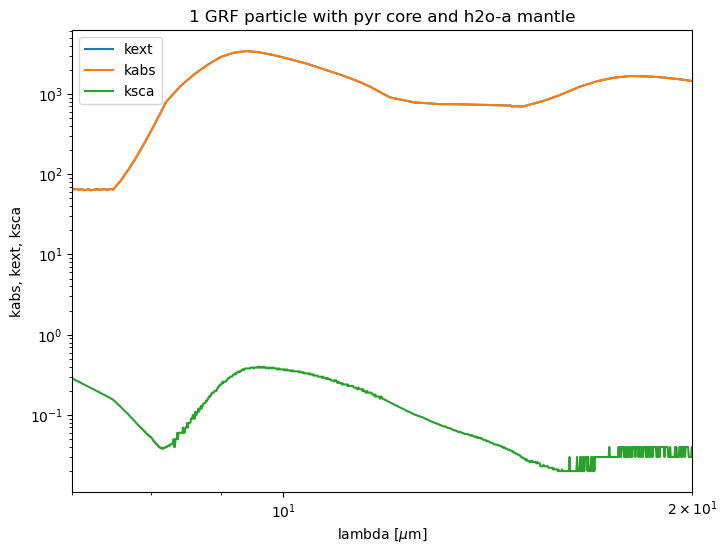

In [9]:
plt.figure(figsize=(8,6))
plt.title('1 GRF particle with pyr core and h2o-a mantle')
plt.plot(lam, kext, label='kext')
plt.plot(lam,kabs,label='kabs')
plt.plot(lam,kext - kabs,label='ksca')
ymin,ymax = plt.ylim()
# plt.vlines(18,ymin,ymax,color='red' )
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlim(lam[0], lam[-1])
plt.ylabel('kabs, kext, ksca')
plt.xlabel(r'lambda [$\mu$m]')
plt.show()


# checking particle library distribution
my general boudaries are about 0.5 for the mantle and idk yet about porosity

In [4]:
from pathlib import Path

particle_files = os.listdir("generating_particles")

i = 1
mantle_frac_list = []
por_frac_list = []
for particle_file in Path("generating_particles").rglob("*.geom"):

    rf = open(particle_file)
    # read in relevant header data
    mantle_volume = 0  # in case theres no mantle
    line = rf.readline()
    while line.startswith("#"):
        if line.startswith("# porosity_frac"):
            porosity_frac = float(line.split()[-1])
        elif line.startswith("# Volume1"):
            core_volume = float(line.split()[-1])
        elif line.startswith("# Volume2"):
            mantle_volume = float(line.split()[-1])
        line = rf.readline()

    rf.close()

    mantle_frac = mantle_volume / (mantle_volume + core_volume)
    mantle_frac_list.append(mantle_frac)
    por_frac_list.append(porosity_frac)
len(list(Path("generating_particles").rglob("*.geom")))

2398

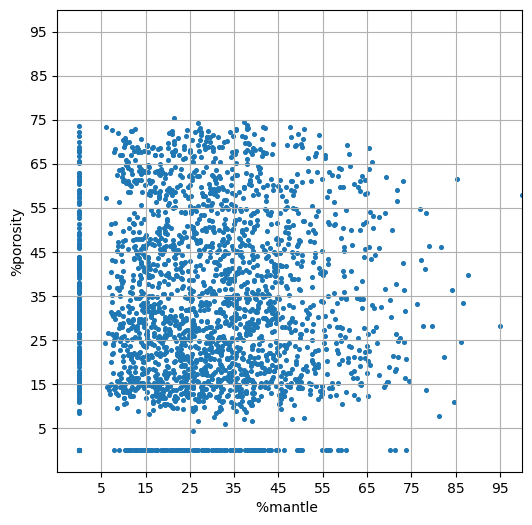

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(mantle_frac_list, por_frac_list, s=7)
plt.xlabel('%mantle ')
plt.ylabel('%porosity')
plt.ylim(-0.05,1)
plt.xlim(-0.05,1)
plt.xticks(np.arange(0.05,1.01, 0.1), range(5,96, 10))
plt.yticks(np.arange(0.05,1.01, 0.1), range(5,96, 10))
plt.grid()
plt.show()


each box here is a bin,

'0123'